In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('train.csv', usecols = ['Age', 'Fare' , 'Survived'])

In [4]:
df.dropna(inplace = True)

In [5]:
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
X_train, X_test , y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [9]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [10]:
clf = DecisionTreeClassifier()

In [11]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [12]:
accuracy_score(y_test, y_pred)

0.6293706293706294

In [13]:
# Cross validation

np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv = 10, scoring= 'accuracy'))

np.float64(0.6261541471048513)

# Discretizer  /  Binning
 
## 1] Equal Width (Uniform)

In [27]:
kbin_age = KBinsDiscretizer(n_bins = 15 , encode = 'ordinal', strategy = 'uniform')
kbin_fare = KBinsDiscretizer(n_bins = 15 , encode = 'ordinal', strategy = 'uniform')


In [28]:
trf = ColumnTransformer([('first', kbin_age, [0]),
                         ('second', kbin_fare,[1])
                        ])

In [29]:

# 2. FIT the transformer first (This is the missing step)
trf.fit(X_train) 

# 3. NOW you can access the attributes
print(trf.named_transformers_['first'].n_bins_)

[15]


# first we have to apply fit method , then only you can perform transform

In [30]:
X_train_trf = trf.fit_transform(X_train) 
X_test_trf =  trf.transform(X_test)

In [31]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15, strategy='uniform'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15, strategy='uniform')}

In [32]:
trf.named_transformers_['first'].n_bins_

array([15])

In [33]:
trf.named_transformers_['second'].n_bins_

array([15])

In [34]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      ,  5.72533333, 11.03066667, 16.336     , 21.64133333,
              26.94666667, 32.252     , 37.55733333, 42.86266667, 48.168     ,
              53.47333333, 58.77866667, 64.084     , 69.38933333, 74.69466667,
              80.        ])                                                   ],
      dtype=object)

In [35]:
output =  pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
})

In [36]:
output.sample(5)

,age,age_trf,fare,fare_trf
780,13.0,2.0,7.2292,0.0
771,48.0,8.0,7.8542,0.0
25,38.0,7.0,31.3875,0.0
493,71.0,13.0,49.5042,1.0
484,25.0,4.0,91.0792,2.0


In [37]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf , y_train)
y_pred2  = clf.predict(X_test_trf)

In [38]:
accuracy_score(y_test, y_pred2)

0.6223776223776224

In [49]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins = bins, encode = 'ordinal', strategy = strategy)
    kbin_fare = KBinsDiscretizer(n_bins = bins, encode = 'ordinal', strategy = strategy)

    trf = ColumnTransformer([
    ('first',kbin_age ,[0]),
    ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv = 10, scoring = 'accuracy')))

    plt.figure(figsize = (14,1))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,0], color = 'red')
    plt.title('After')

    plt.show()

    
    plt.figure(figsize = (14,1))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,0], color = 'red')
    #plt.title('After')
    plt.title('Fare')

    plt.show()

0.6330594679186229


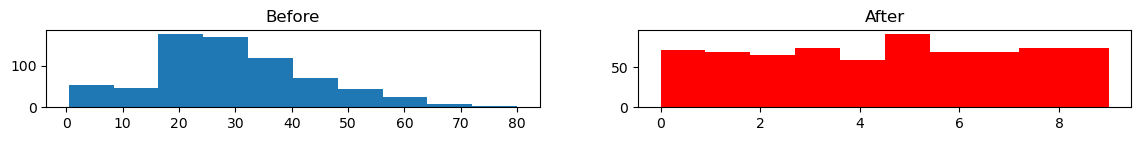

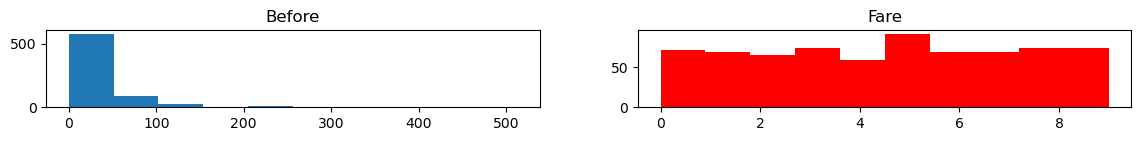

In [50]:
discretize(10, 'quantile')

## Right Skewd data get spread Uniformly

0.6330790297339592


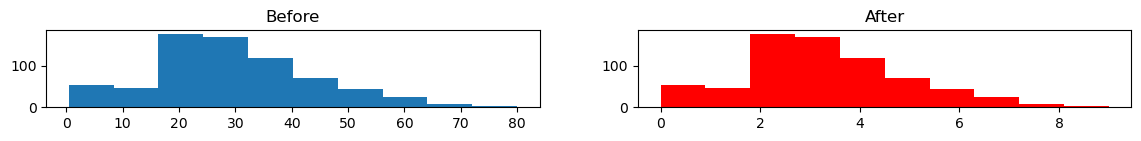

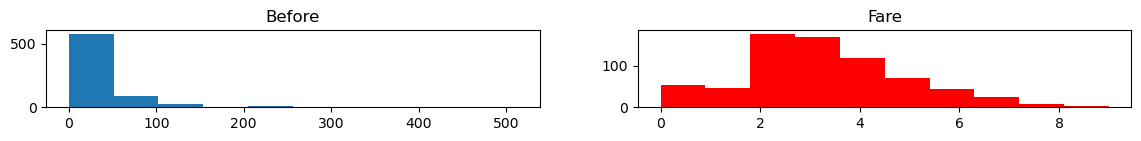

In [51]:
discretize(10, 'uniform')


## Results are almost same

C:\Users\sangr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\sangr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6331377151799688


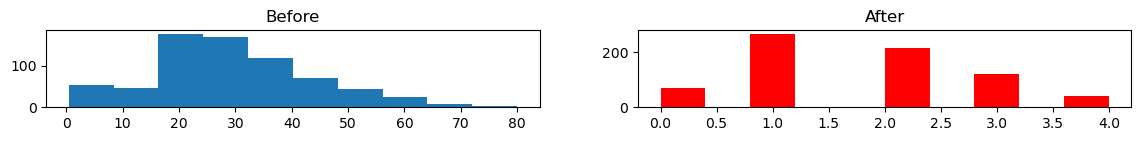

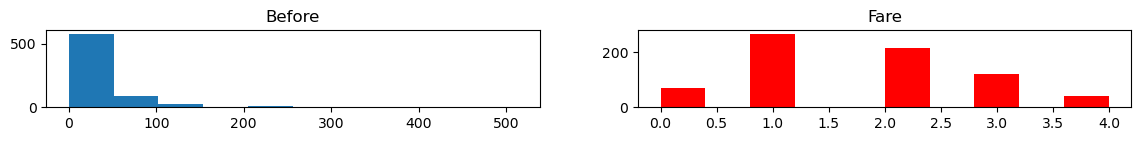

In [53]:
discretize(5, 'kmeans')

# Results are more about same

# Custom / Domain Based Binning

- It is used when we have to use more than 1 binning at a time
- we have write code in pandas here , we can't use SKLearn here
- Apne Hisabse se Binning tayar karna